# Бэггинг (Bagging)

**Bagging = Bootstrap AGGregatING**

Идея: обучить много моделей на разных подвыборках данных и усреднить их предсказания.  
Каждая подвыборка создаётся **бутстрепом** - случайной выборкой с возвращением.

Random Forest - это частный случай бэггинга над деревьями решений.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

## 1. Загрузка данных

Используем Wine dataset — тот же что в лабе 4 и 7.
178 образцов вина, 13 химических признаков, 3 класса.

In [2]:
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Трейн: {X_train.shape}, Тест: {X_test.shape}")
print(f"Классы (0/1/2): {np.bincount(y)}")

Трейн: (133, 13), Тест: (45, 13)
Классы (0/1/2): [59 71 48]


## 2. Бутстреп - основа бэггинга

Бутстреп: берём датасет из N объектов и N раз случайно вытаскиваем объект **с возвращением**.  
В среднем ~63% уникальных объектов попадут в подвыборку, ~37% — нет (out-of-bag).  
Каждая подвыборка немного отличается → каждое дерево учится на слегка разных данных → деревья разные.

In [3]:
N = len(X_train)
bootstrap_idx = np.random.choice(N, size=N, replace=True)  # replace=True = с возвращением
oob_idx = np.setdiff1d(np.arange(N), bootstrap_idx)        # объекты которые не попали

print(f"Всего объектов в трейне: {N}")
print(f"Уникальных в бутстреп-выборке: {len(np.unique(bootstrap_idx))} ({len(np.unique(bootstrap_idx))/N*100:.1f}%)")
print(f"Out-of-bag (не попали): {len(oob_idx)} ({len(oob_idx)/N*100:.1f}%)")

Всего объектов в трейне: 133
Уникальных в бутстреп-выборке: 80 (60.2%)
Out-of-bag (не попали): 53 (39.8%)


## 3. Бэггинг вручную - чтобы понять механику

Обучаем 10 деревьев на разных бутстреп-выборках, предсказываем голосованием большинства.

In [4]:
n_estimators = 10
trees = []

for i in range(n_estimators):
    # Создаём бутстреп-выборку
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]

    # Обучаем одно дерево
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_boot, y_boot)
    trees.append(tree)

    acc = accuracy_score(y_test, tree.predict(X_test))
    print(f"Дерево {i+1:2d}: accuracy = {acc:.3f}")

# Голосование: для каждого объекта берём самый частый класс среди 10 деревьев
# predictions.shape = (n_estimators, n_test)
predictions = np.array([tree.predict(X_test) for tree in trees])
final_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)

print(f"\nАнсамбль из {n_estimators} деревьев: accuracy = {accuracy_score(y_test, final_preds):.3f}")

Дерево  1: accuracy = 0.889
Дерево  2: accuracy = 0.911
Дерево  3: accuracy = 0.911
Дерево  4: accuracy = 0.911
Дерево  5: accuracy = 0.933
Дерево  6: accuracy = 0.867
Дерево  7: accuracy = 0.867
Дерево  8: accuracy = 0.867
Дерево  9: accuracy = 0.733
Дерево 10: accuracy = 0.978

Ансамбль из 10 деревьев: accuracy = 0.978


## 4. BaggingClassifier из sklearn

То же самое, но через sklearn. Плюс - OOB score: бесплатная оценка качества на out-of-bag объектах,  
которые не попали в обучение конкретного дерева. Это как встроенная кросс-валидация.

In [5]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,   # количество деревьев
    max_samples=1.0,    # доля объектов в каждой подвыборке
    max_features=1.0,   # доля признаков (1.0 = все признаки)
    bootstrap=True,     # с возвращением
    oob_score=True,     # оценка на out-of-bag
    random_state=42
)

bagging.fit(X_train, y_train)

print(f"BaggingClassifier accuracy (тест): {accuracy_score(y_test, bagging.predict(X_test)):.3f}")
print(f"OOB score (бесплатная оценка):     {bagging.oob_score_:.3f}")

BaggingClassifier accuracy (тест): 1.000
OOB score (бесплатная оценка):     0.955


## 5. Random Forest - бэггинг + случайные признаки

Random Forest добавляет ещё один уровень случайности: при каждом разбиении узла  
дерево выбирает лучший признак **не из всех 13, а из случайного подмножества** (~√13 ≈ 4).  
Это делает деревья более разнообразными → ансамбль точнее.

In [6]:
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Сравнение моделей:")
print(f"  Одно дерево:        {accuracy_score(y_test, single_tree.predict(X_test)):.3f}")
print(f"  Bagging (100 дер.): {accuracy_score(y_test, bagging.predict(X_test)):.3f}")
print(f"  Random Forest:      {accuracy_score(y_test, rf.predict(X_test)):.3f}")

Сравнение моделей:
  Одно дерево:        0.956
  Bagging (100 дер.): 1.000
  Random Forest:      1.000


## 6. Важность признаков

Random Forest считает важность каждого признака - насколько часто и сильно
он уменьшал Gini при разбиениях по всем деревьям.

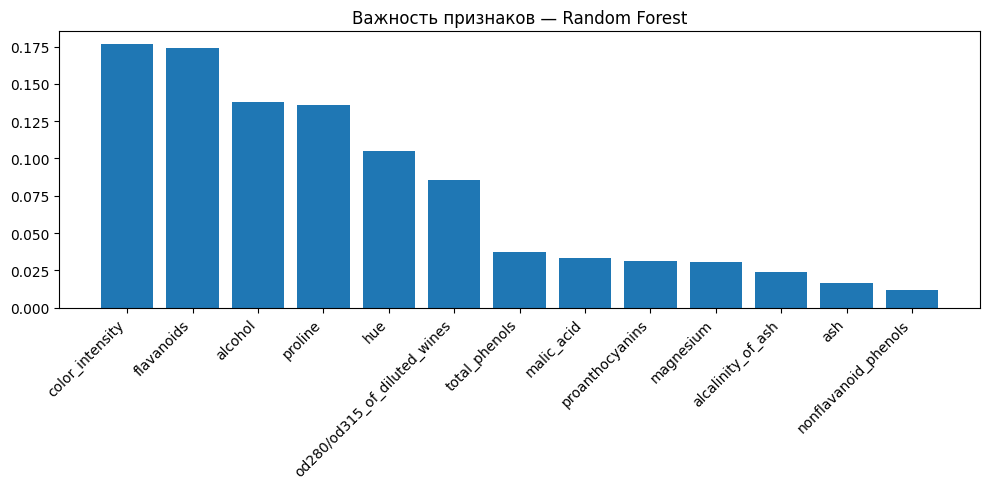

Топ-3 признака:
  color_intensity: 0.176
  flavanoids: 0.174
  alcohol: 0.138


In [7]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [wine.feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Важность признаков — Random Forest')
plt.tight_layout()
plt.show()

print("Топ-3 признака:")
for i in range(3):
    print(f"  {wine.feature_names[indices[i]]}: {importances[indices[i]]:.3f}")

## 7. Как количество деревьев влияет на качество

n_estimators=   1: cv accuracy = 0.838
n_estimators=   2: cv accuracy = 0.849
n_estimators=   5: cv accuracy = 0.916
n_estimators=  10: cv accuracy = 0.950
n_estimators=  20: cv accuracy = 0.961
n_estimators=  50: cv accuracy = 0.961
n_estimators= 100: cv accuracy = 0.972
n_estimators= 200: cv accuracy = 0.967


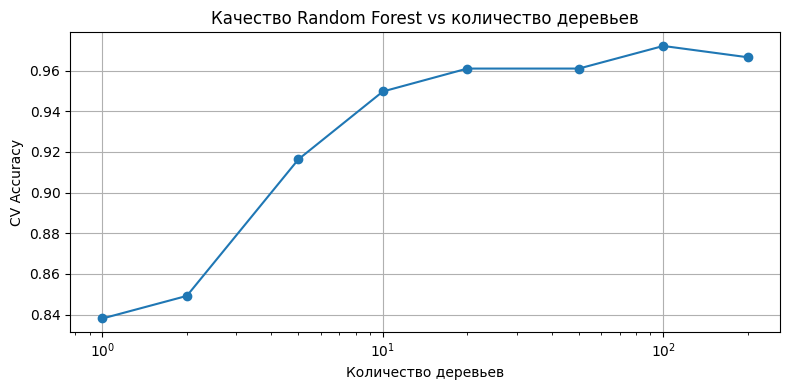

In [8]:
n_trees_range = [1, 2, 5, 10, 20, 50, 100, 200]
scores = []

for n in n_trees_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf_temp, X, y, cv=5).mean()
    scores.append(score)
    print(f"n_estimators={n:4d}: cv accuracy = {score:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(n_trees_range, scores, marker='o')
plt.xlabel('Количество деревьев')
plt.ylabel('CV Accuracy')
plt.title('Качество Random Forest vs количество деревьев')
plt.xscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()